## Data load

Data pipeline disamakan dengan `pretrained_model_localization.ipynb`: label order `NORM/IMI/AMI/LMI`, patient-level split dipakai bila file `x_all.npy`, `y_all.npy`, dan `patient_ids_all.npy` tersedia, lalu normalisasi per-lead z-score difit hanya dari train.


In [1]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
)


In [2]:
PROJECT_ROOT = Path('..').resolve() if Path.cwd().name == 'notebook' else Path('.').resolve()
DATA_DIR = PROJECT_ROOT / 'data_ready'
SAVE_DIR = PROJECT_ROOT / 'model_pretrain_comparison'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

class_names = ["NORM", "IMI", "AMI", "LMI"]
label_to_idx = {name: i for i, name in enumerate(class_names)}
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

CONFIG = {
    'seed': 42,
    'batch_size': 32,
    'epochs': 100,
    'use_early_stopping': False,
    'patience': None,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'gradient_clip_norm': 2.0,
    'normalization': 'per_lead_zscore_from_train',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG['seed'])
device = torch.device(CONFIG['device'])
print(json.dumps(CONFIG, indent=2))
print('DATA_DIR:', DATA_DIR)
print('SAVE_DIR:', SAVE_DIR)
print('Device:', device)


{
  "seed": 42,
  "batch_size": 32,
  "epochs": 100,
  "use_early_stopping": false,
  "patience": null,
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "gradient_clip_norm": 2.0,
  "normalization": "per_lead_zscore_from_train",
  "device": "cuda"
}
DATA_DIR: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-classification/data_ready
SAVE_DIR: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-classification/model_pretrain_comparison
Device: cuda


In [3]:
def load_split(data_dir, split):
    x = np.load(data_dir / f'x_{split}.npy').astype(np.float32)
    y = np.load(data_dir / f'y_{split}.npy')
    if y.ndim > 1 and y.shape[1] > 1:
        y_idx = y.argmax(axis=1).astype(np.int64)
    else:
        y_idx = y.reshape(-1).astype(np.int64)
    return x, y_idx

x_train_old, y_train_old = load_split(DATA_DIR, 'train')
x_val_old, y_val_old = load_split(DATA_DIR, 'val')
x_test_old, y_test_old = load_split(DATA_DIR, 'test')

for name, x, y in [('train_old', x_train_old, y_train_old), ('val_old', x_val_old, y_val_old), ('test_old', x_test_old, y_test_old)]:
    print(name, x.shape, np.bincount(y, minlength=len(class_names)))

assert x_train_old.ndim == 3 and x_train_old.shape[2] == len(lead_names), 'Expected ECG shape [N, length, 12 leads].' 


train_old (9735, 1000, 12) [6668 1596 1398   73]
val_old (1391, 1000, 12) [953 228 200  10]
test_old (2784, 1000, 12) [1906  457  400   21]


In [4]:
def validate_ecg_array(x, name):
    if x.ndim != 3:
        raise ValueError(f'{name}: expected [N, length, leads], got {x.shape}')
    if x.shape[2] != len(lead_names):
        raise ValueError(f'{name}: expected 12 leads, got {x.shape[2]}')
    if not np.isfinite(x).all():
        raise ValueError(f'{name}: contains NaN or Inf')

def check_patient_leakage(patient_train, patient_val, patient_test):
    train_set = set(map(str, patient_train))
    val_set = set(map(str, patient_val))
    test_set = set(map(str, patient_test))
    leakage = {
        'train_val': sorted(train_set & val_set),
        'train_test': sorted(train_set & test_set),
        'val_test': sorted(val_set & test_set),
    }
    total_leaks = sum(len(v) for v in leakage.values())
    if total_leaks:
        raise RuntimeError(f'PATIENT LEAKAGE DETECTED: {leakage}')
    return leakage

for split_name, x in [('train_old', x_train_old), ('val_old', x_val_old), ('test_old', x_test_old)]:
    validate_ecg_array(x, split_name)

all_paths = [DATA_DIR / 'x_all.npy', DATA_DIR / 'y_all.npy', DATA_DIR / 'patient_ids_all.npy']
patient_level_available = all(p.exists() for p in all_paths)

if patient_level_available:
    x_all = np.load(DATA_DIR / 'x_all.npy').astype(np.float32)
    y_all = np.load(DATA_DIR / 'y_all.npy')
    patient_ids_all = np.load(DATA_DIR / 'patient_ids_all.npy', allow_pickle=True)
    y_all_idx = y_all.argmax(axis=1).astype(np.int64) if y_all.ndim > 1 else y_all.reshape(-1).astype(np.int64)

    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=CONFIG['seed'])
    train_val_idx, test_idx = next(gss.split(x_all, y_all_idx, groups=patient_ids_all))
    gss_val = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=CONFIG['seed'])
    train_rel, val_rel = next(gss_val.split(x_all[train_val_idx], y_all_idx[train_val_idx], groups=patient_ids_all[train_val_idx]))
    train_idx = train_val_idx[train_rel]
    val_idx = train_val_idx[val_rel]

    x_train, y_train = x_all[train_idx], y_all_idx[train_idx]
    x_val, y_val = x_all[val_idx], y_all_idx[val_idx]
    x_test, y_test = x_all[test_idx], y_all_idx[test_idx]
    check_patient_leakage(patient_ids_all[train_idx], patient_ids_all[val_idx], patient_ids_all[test_idx])
    split_warning = None
    print('Patient-level split used and leakage check passed.')
else:
    warnings.warn(
        'PATIENT_ID NOT AVAILABLE. Existing split is used. Patient leakage cannot be ruled out.',
        RuntimeWarning,
    )
    x_train, y_train = x_train_old, y_train_old
    x_val, y_val = x_val_old, y_val_old
    x_test, y_test = x_test_old, y_test_old
    split_warning = 'patient_id unavailable; existing split used; patient leakage cannot be ruled out'

for name, x, y in [('train', x_train, y_train), ('val', x_val, y_val), ('test', x_test, y_test)]:
    validate_ecg_array(x, name)
    print(name, x.shape, np.bincount(y, minlength=len(class_names)))


Patient-level split used and leakage check passed.
train (9733, 1000, 12) [6675 1591 1398   69]
val (1403, 1000, 12) [937 247 211   8]
test (2774, 1000, 12) [1915  443  389   27]


In [5]:
class PerLeadZScore:
    def __init__(self, eps=1e-6):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, x):
        self.mean_ = x.mean(axis=(0, 1), keepdims=True)
        self.std_ = np.maximum(x.std(axis=(0, 1), keepdims=True), self.eps)
        return self

    def transform(self, x):
        if self.mean_ is None or self.std_ is None:
            raise RuntimeError('Normalizer must be fit on train first.')
        return ((x - self.mean_) / self.std_).astype(np.float32)

normalizer = PerLeadZScore().fit(x_train)
x_train = normalizer.transform(x_train)
x_val = normalizer.transform(x_val)
x_test = normalizer.transform(x_test)

np.savez(
    SAVE_DIR / 'normalization_stats_train_only.npz',
    mean=normalizer.mean_,
    std=normalizer.std_,
    lead_names=np.array(lead_names),
)

# Keep tensors in [N, length, channels]. Individual model cells permute to [N, channels, length] when needed.
x_train = torch.tensor(x_train, dtype=torch.float32)
x_val = torch.tensor(x_val, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

batch_size = CONFIG['batch_size']
train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=batch_size, shuffle=False)

print('Train-only per-lead z-score normalization applied.')
print('Train:', x_train.shape, y_train.shape)
print('Val  :', x_val.shape, y_val.shape)
print('Test :', x_test.shape, y_test.shape)


Train-only per-lead z-score normalization applied.
Train: torch.Size([9733, 1000, 12]) torch.Size([9733])
Val  : torch.Size([1403, 1000, 12]) torch.Size([1403])
Test : torch.Size([2774, 1000, 12]) torch.Size([2774])


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Helper cell only.
# Tidak ada load model lama dan tidak ada eksekusi otomatis di cell ini.
# Gunakan helper ini setelah model baru selesai dibuat/dilatih di cell training.

def to_numpy_label(y):
    if isinstance(y, torch.Tensor):
        y = y.detach().cpu().numpy()
    else:
        y = np.asarray(y)
    if y.ndim > 1 and y.shape[1] > 1:
        y = np.argmax(y, axis=1)
    return y.reshape(-1).astype(int)


def ensure_channel_first(xb, expected_channels=12):
    """Terima input [B,L,C] atau [B,C,L], kembalikan [B,C,L]."""
    if xb.dim() == 3 and xb.shape[1] != expected_channels and xb.shape[2] == expected_channels:
        return xb.permute(0, 2, 1)
    return xb


def eval_model(model, dl, name="Evaluation", device=None, class_names=None, expected_channels=12):
    """Evaluasi model yang sudah ada, tanpa meload file .pth apa pun.

    Contoh pemakaian setelah training model baru:
        eval_model(model, val_loader, "Validation", device, class_names)
        eval_model(model, test_loader, "Test", device, class_names)
    """
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb = ensure_channel_first(xb.to(device).float(), expected_channels=expected_channels)
            out = model(xb)
            preds = out.argmax(1).detach().cpu().numpy()
            y_pred.append(preds)
            y_true.append(to_numpy_label(yb))

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)

    if class_names is None:
        class_names = [str(i) for i in sorted(np.unique(y_true))]

    print(f"\n{name} - Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return {"accuracy": acc, "confusion_matrix": cm, "y_true": y_true, "y_pred": y_pred}

# Tidak menjalankan apa pun di bawah ini.
# Notebook ini akan membuat/pretrain model baru pada cell training, lalu helper ini bisa dipanggil bila diperlukan.


## Comparison models

### cnn 1d

Detected classes: 4 | Channels: 12 | Seq length: 1000
Epoch 01/100 | Loss 1.1062/0.7869 | Acc 0.6243/0.7855
Epoch 02/100 | Loss 0.7833/0.6458 | Acc 0.7879/0.8154
Epoch 03/100 | Loss 0.6353/0.5396 | Acc 0.8246/0.8396
Epoch 04/100 | Loss 0.5524/0.4964 | Acc 0.8467/0.8460
Epoch 05/100 | Loss 0.4924/0.4375 | Acc 0.8545/0.8525
Epoch 06/100 | Loss 0.4575/0.4091 | Acc 0.8635/0.8632
Epoch 07/100 | Loss 0.4236/0.3877 | Acc 0.8700/0.8653
Epoch 08/100 | Loss 0.3989/0.3623 | Acc 0.8724/0.8774
Epoch 09/100 | Loss 0.3851/0.3566 | Acc 0.8779/0.8703
Epoch 10/100 | Loss 0.3714/0.3433 | Acc 0.8806/0.8746
Epoch 11/100 | Loss 0.3660/0.3304 | Acc 0.8822/0.8838
Epoch 12/100 | Loss 0.3528/0.3411 | Acc 0.8842/0.8803
Epoch 13/100 | Loss 0.3582/0.3141 | Acc 0.8825/0.8867
Epoch 14/100 | Loss 0.3453/0.3142 | Acc 0.8849/0.8909
Epoch 15/100 | Loss 0.3308/0.3029 | Acc 0.8886/0.8909
Epoch 16/100 | Loss 0.3247/0.3119 | Acc 0.8928/0.8838
Epoch 17/100 | Loss 0.3274/0.2954 | Acc 0.8922/0.8974
Epoch 18/100 | Loss 0.3178/0

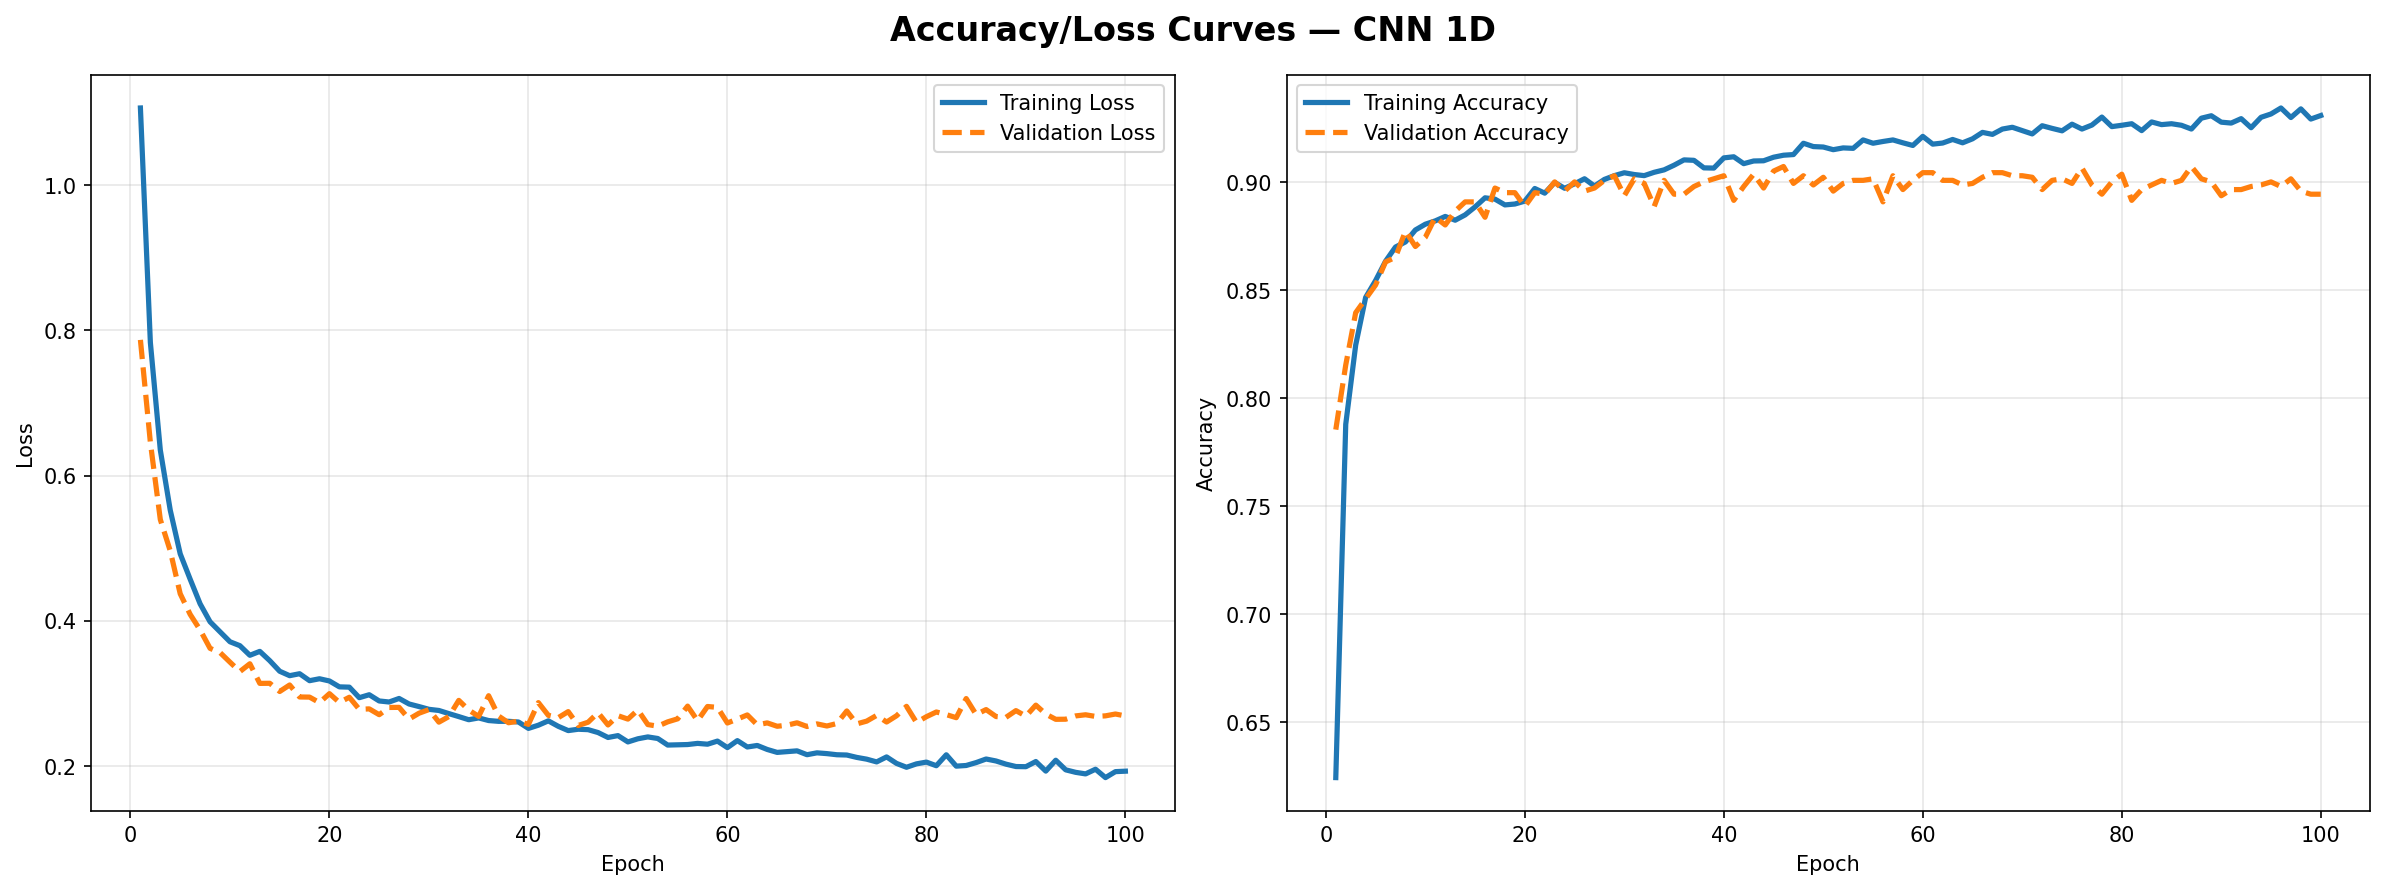


Validation — Accuracy: 0.8945
              precision    recall  f1-score   support

        NORM       0.92      0.95      0.93       937
         IMI       0.81      0.81      0.81       247
         AMI       0.88      0.78      0.83       211
         LMI       0.00      0.00      0.00         8

    accuracy                           0.89      1403
   macro avg       0.65      0.64      0.64      1403
weighted avg       0.89      0.89      0.89      1403



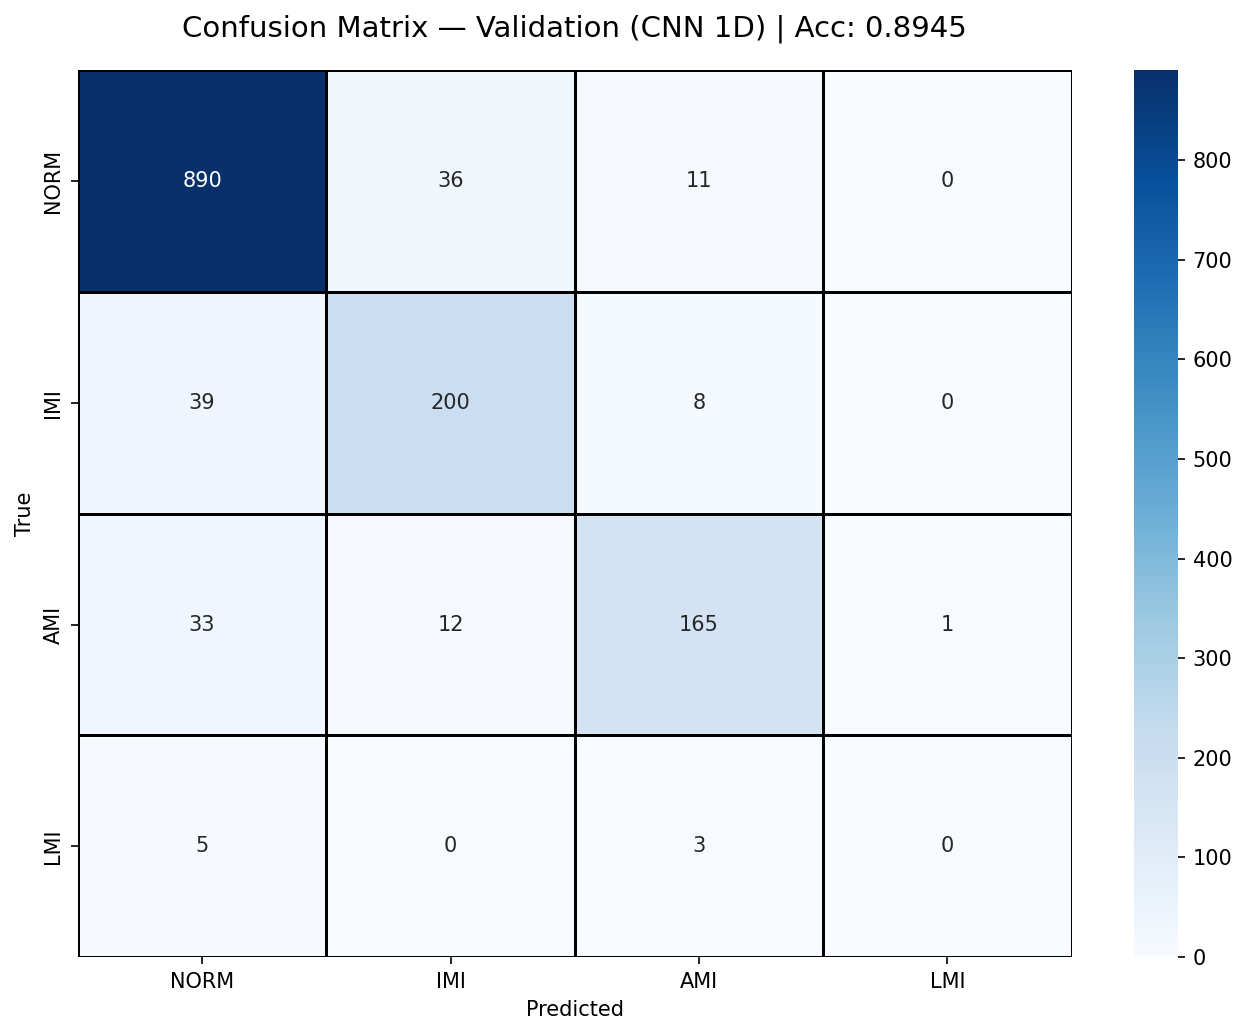


Test — Accuracy: 0.8976
              precision    recall  f1-score   support

        NORM       0.93      0.95      0.94      1915
         IMI       0.79      0.81      0.80       443
         AMI       0.83      0.81      0.82       389
         LMI       0.00      0.00      0.00        27

    accuracy                           0.90      2774
   macro avg       0.64      0.64      0.64      2774
weighted avg       0.89      0.90      0.89      2774



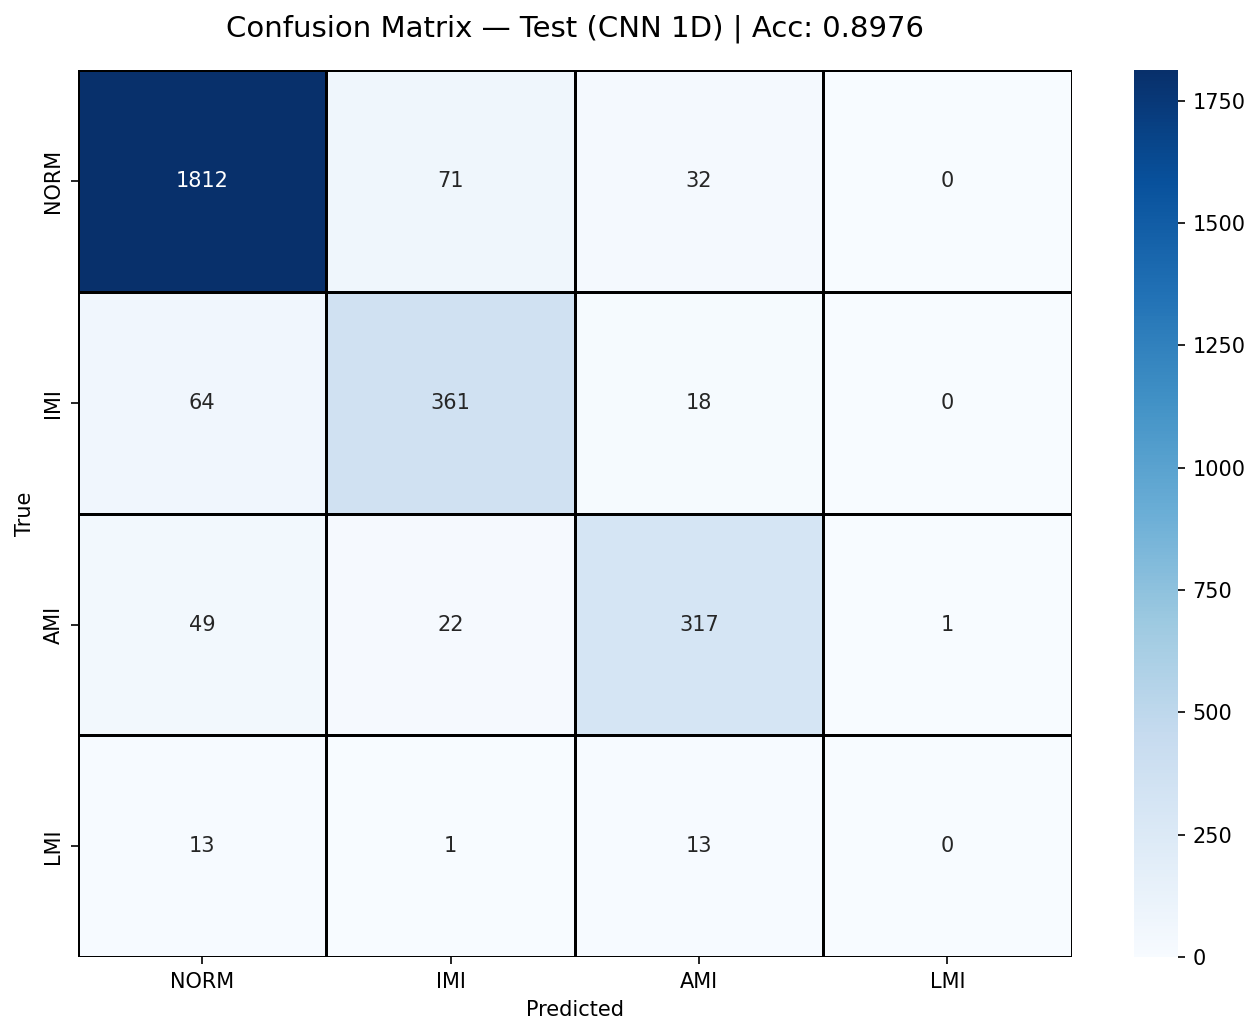

In [7]:
# === CNN 1D (Multiclass NORM-IMI-AMI-LMI) ===
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ---------------------------------------
# 1) Dataset Prep (reuse data)
# ---------------------------------------
def to_numpy_array(a):
    if isinstance(a, torch.Tensor):
        return a.detach().cpu().numpy()
    return np.asarray(a)

def to_index(y):
    y_np = to_numpy_array(y)
    if y_np.ndim > 1 and y_np.shape[1] > 1:
        return np.argmax(y_np, axis=1).astype(np.int64)
    return y_np.reshape(-1).astype(np.int64)

y_train_idx = to_index(y_train)
y_val_idx   = to_index(y_val)
y_test_idx  = to_index(y_test)

num_classes = len(class_names)
in_channels = x_train.shape[2]
seq_len = x_train.shape[1]
print(f"Detected classes: {num_classes} | Channels: {in_channels} | Seq length: {seq_len}")

def make_loader(X, y, bs=128, shuffle=True):
    X = torch.as_tensor(to_numpy_array(X), dtype=torch.float32).permute(0, 2, 1)  # [B,C,L]
    y = torch.as_tensor(to_index(y), dtype=torch.long)
    return DataLoader(TensorDataset(X, y), batch_size=bs, shuffle=shuffle, num_workers=0)

train_loader = make_loader(x_train, y_train_idx)
val_loader   = make_loader(x_val, y_val_idx, shuffle=False)
test_loader  = make_loader(x_test, y_test_idx, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---------------------------------------
# 2) Model Definition — CNN 1D 
# ---------------------------------------
class ECG1DNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(16),
            nn.MaxPool1d(2),              

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(2),             

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
        )

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.6),              # naikkan dropout
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


# ---------------------------------------
# 3) Training Setup 
# ---------------------------------------
model = ECG1DNet(in_channels=in_channels, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-4)

def run_epoch(dl, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)  # xb already [B,C,L]
            out = model(xb)
            loss = criterion(out, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            pred = out.argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    return total_loss / total, correct / total

# ---------------------------------------
# 4) Training Loop 
# ---------------------------------------
EPOCHS = 100
hist = {'tr_loss':[], 'va_loss':[], 'tr_acc':[], 'va_acc':[]}

for ep in range(1, EPOCHS+1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader, train=False)
    hist['tr_loss'].append(tr_loss); hist['va_loss'].append(va_loss)
    hist['tr_acc'].append(tr_acc);   hist['va_acc'].append(va_acc)
    print(f"Epoch {ep:02d}/{EPOCHS} | Loss {tr_loss:.4f}/{va_loss:.4f} | Acc {tr_acc:.4f}/{va_acc:.4f}")

# ---------------------------------------
# 5) Plot Curves 
# ---------------------------------------
ep = np.arange(1, len(hist['tr_loss'])+1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

ax1.plot(ep, hist['tr_loss'], label='Training Loss', linewidth=2.5)
ax1.plot(ep, hist['va_loss'], label='Validation Loss', linewidth=2.5, linestyle='--')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, hist['tr_acc'], label='Training Accuracy', linewidth=2.5)
ax2.plot(ep, hist['va_acc'], label='Validation Accuracy', linewidth=2.5, linestyle='--')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

fig.suptitle('Accuracy/Loss Curves — CNN 1D', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ---------------------------------------
# 6) Evaluation + Confusion Matrix 
# ---------------------------------------
LABEL_ORDER = class_names
LABELS = list(range(len(class_names)))

def eval_model(dl, name):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(device)
            out = model(xb)
            preds = out.argmax(1).cpu().numpy()
            y_pred.append(preds)
            y_true.append(yb.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{name} — Accuracy: {acc:.4f}")
    print(classification_report(
        y_true, y_pred,
        target_names=LABEL_ORDER,
        labels=LABELS,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred, labels=LABELS)

    plt.figure(figsize=(9, 7), dpi=150)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=LABEL_ORDER,
        yticklabels=LABEL_ORDER,
        linewidths=0.7, linecolor='black'
    )
    plt.title(f'Confusion Matrix — {name} (CNN 1D) | Acc: {acc:.4f}', fontsize=14, pad=16)
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    plt.show()

eval_model(val_loader,  "Validation")
eval_model(test_loader, "Test")


In [8]:
# Save the trained model
model_name = 'cnn1d'
save_path = SAVE_DIR / f'{model_name}.pth'

# Ensure the directory exists
SAVE_DIR.mkdir(parents=True, exist_ok=True)
# Save the model state_dict
torch.save(model.state_dict(), save_path)
print(f"Model saved at {save_path}")


Model saved at /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-classification/model_pretrain_comparison/cnn1d.pth


### LSTM



In [11]:
# === LSTM (Multiclass NORM–AMI–IMI–LMI) ===

# ---------------------------------------
# 1) Dataset Prep 
# ---------------------------------------
def to_numpy_array(a):
    if isinstance(a, torch.Tensor):
        return a.detach().cpu().numpy()
    return np.asarray(a)

def to_index(y):
    y_np = to_numpy_array(y)
    if y_np.ndim > 1 and y_np.shape[1] > 1:
        return np.argmax(y_np, axis=1).astype(np.int64)
    return y_np.reshape(-1).astype(np.int64)

y_train_idx = to_index(y_train)
y_val_idx   = to_index(y_val)
y_test_idx  = to_index(y_test)

num_classes = len(class_names)
in_channels = x_train.shape[2]
seq_len = x_train.shape[1]
print(f"Detected classes: {num_classes} | Channels: {in_channels} | Seq length: {seq_len}")

def make_loader(X, y, bs=128, shuffle=True):
    X = torch.as_tensor(to_numpy_array(X), dtype=torch.float32)  # [B,L,C]
    y = torch.as_tensor(to_index(y), dtype=torch.long)
    return DataLoader(TensorDataset(X, y), batch_size=bs, shuffle=shuffle, num_workers=0)

train_loader = make_loader(x_train, y_train_idx)
val_loader   = make_loader(x_val, y_val_idx, shuffle=False)
test_loader  = make_loader(x_test, y_test_idx, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---------------------------------------
# 2) Model Definition — LSTM 
# ---------------------------------------
class LSTM_Only_Multi(nn.Module):
    def __init__(self, input_size, num_classes, hidden_size=128, num_layers=3, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):        # x: [B,L,C]
        out, _ = self.lstm(x)    # [B,L,H]
        feat = out[:, -1, :]     # last timestep pooling
        return self.head(feat)

# ---------------------------------------
# 3) Training Setup
# ---------------------------------------
model = LSTM_Only_Multi(input_size=in_channels, num_classes=num_classes, hidden_size=128, num_layers=3, dropout=0.2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-7)

def run_epoch(dl, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)  # xb: [B,L,C]
            out = model(xb)
            loss = criterion(out, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            pred = out.argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    return total_loss / total, correct / total

# ---------------------------------------
# 4) Training Loop
# ---------------------------------------
EPOCHS = 100
hist = {'tr_loss':[], 'va_loss':[], 'tr_acc':[], 'va_acc':[]}

for ep in range(1, EPOCHS+1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader, train=False)
    hist['tr_loss'].append(tr_loss); hist['va_loss'].append(va_loss)
    hist['tr_acc'].append(tr_acc);   hist['va_acc'].append(va_acc)
    print(f"Epoch {ep:02d}/{EPOCHS} | Loss {tr_loss:.4f}/{va_loss:.4f} | Acc {tr_acc:.4f}/{va_acc:.4f}")

# ---------------------------------------
# 5) Plot Curves 
# ---------------------------------------
ep = np.arange(1, len(hist['tr_loss'])+1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

ax1.plot(ep, hist['tr_loss'], label='Training Loss', linewidth=2.5)
ax1.plot(ep, hist['va_loss'], label='Validation Loss', linewidth=2.5, linestyle='--')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, hist['tr_acc'], label='Training Accuracy', linewidth=2.5)
ax2.plot(ep, hist['va_acc'], label='Validation Accuracy', linewidth=2.5, linestyle='--')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

fig.suptitle('Accuracy/Loss Curves — LSTM', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ---------------------------------------
# 6) Evaluation + Confusion Matrix 
# ---------------------------------------
LABEL_ORDER = class_names
LABELS = list(range(len(class_names)))

def eval_model(dl, name):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(device)
            out = model(xb)
            preds = out.argmax(1).cpu().numpy()
            y_pred.append(preds)
            y_true.append(yb.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{name} — Accuracy: {acc:.4f}")
    print(classification_report(
        y_true, y_pred,
        target_names=LABEL_ORDER,
        labels=LABELS,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred, labels=LABELS)

    plt.figure(figsize=(9, 7), dpi=150)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=LABEL_ORDER,
        yticklabels=LABEL_ORDER,
        linewidths=0.7, linecolor='black'
    )
    plt.title(f'Confusion Matrix — {name} (LSTM) | Acc: {acc:.4f}', fontsize=14, pad=16)
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    plt.show()

eval_model(val_loader,  "Validation")
eval_model(test_loader, "Test")


Detected classes: 4 | Channels: 12 | Seq length: 1000


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.35 GiB. GPU 0 has a total capacity of 11.62 GiB of which 288.62 MiB is free. Process 38085 has 235.75 MiB memory in use. Process 40839 has 38.91 MiB memory in use. Process 53383 has 89.91 MiB memory in use. Process 53520 has 46.66 MiB memory in use. Process 77862 has 7.67 GiB memory in use. Process 77969 has 562.00 MiB memory in use. Including non-PyTorch memory, this process has 1.60 GiB memory in use. Of the allocated memory 109.97 MiB is allocated by PyTorch, and 1.35 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
# Save the trained model
model_name = 'lstm'
save_path = SAVE_DIR / f'{model_name}.pth'

# Ensure the directory exists
SAVE_DIR.mkdir(parents=True, exist_ok=True)
# Save the model state_dict
torch.save(model.state_dict(), save_path)
print(f"Model saved at {save_path}")


Model saved at /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-classification/model_pretrain_comparison/lstm.pth


### GRU

Detected classes: 4 | Channels: 12 | Seq length: 1000


/tmp/ipykernel_11465/1962354889.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float32)  # [B,L,C] for GRU


Epoch 01/100 | Loss 0.9239/0.8673 | Acc 0.6834/0.6736
Epoch 02/100 | Loss 0.7337/0.6153 | Acc 0.7138/0.7505
Epoch 03/100 | Loss 0.5314/0.4954 | Acc 0.7907/0.8147
Epoch 04/100 | Loss 0.4678/0.4500 | Acc 0.8415/0.8532
Epoch 05/100 | Loss 0.4023/0.4247 | Acc 0.8676/0.8667
Epoch 06/100 | Loss 0.3750/0.3535 | Acc 0.8734/0.8696
Epoch 07/100 | Loss 0.3334/0.2834 | Acc 0.8849/0.8988
Epoch 08/100 | Loss 0.2942/0.2849 | Acc 0.9001/0.8974
Epoch 09/100 | Loss 0.2817/0.2702 | Acc 0.9026/0.8974
Epoch 10/100 | Loss 0.2698/0.3252 | Acc 0.9068/0.8967
Epoch 11/100 | Loss 0.2634/0.2593 | Acc 0.9084/0.9059
Epoch 12/100 | Loss 0.2601/0.2482 | Acc 0.9107/0.9073
Epoch 13/100 | Loss 0.2514/0.2700 | Acc 0.9146/0.9052
Epoch 14/100 | Loss 0.2416/0.2708 | Acc 0.9182/0.8967
Epoch 15/100 | Loss 0.2394/0.2574 | Acc 0.9147/0.9002
Epoch 16/100 | Loss 0.2350/0.2583 | Acc 0.9199/0.9045
Epoch 17/100 | Loss 0.2208/0.2959 | Acc 0.9236/0.8902
Epoch 18/100 | Loss 0.2380/0.2502 | Acc 0.9164/0.9081
Epoch 19/100 | Loss 0.2155/0

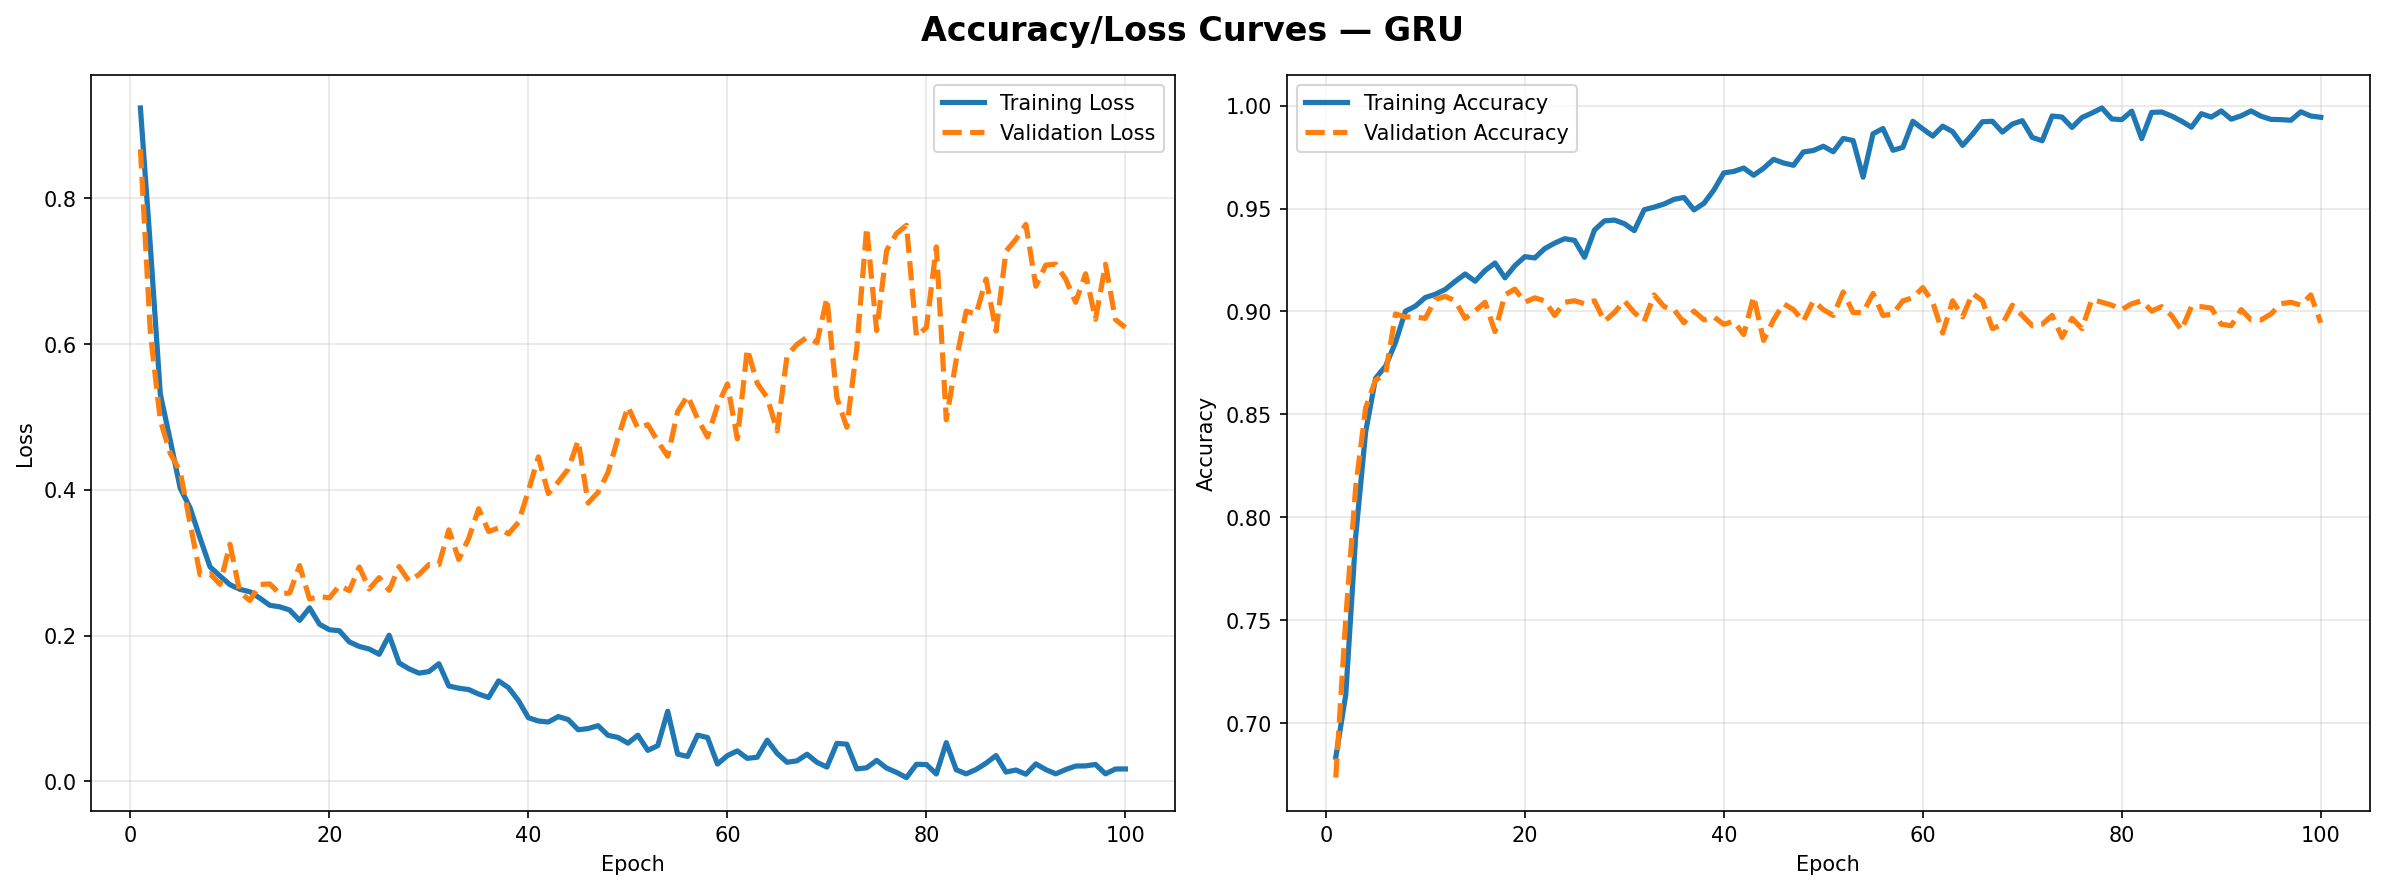


Validation — Accuracy: 0.8945
              precision    recall  f1-score   support

        NORM       0.94      0.93      0.93       937
         IMI       0.77      0.82      0.80       247
         AMI       0.87      0.85      0.86       211
         LMI       0.40      0.25      0.31         8

    accuracy                           0.89      1403
   macro avg       0.75      0.71      0.72      1403
weighted avg       0.89      0.89      0.89      1403



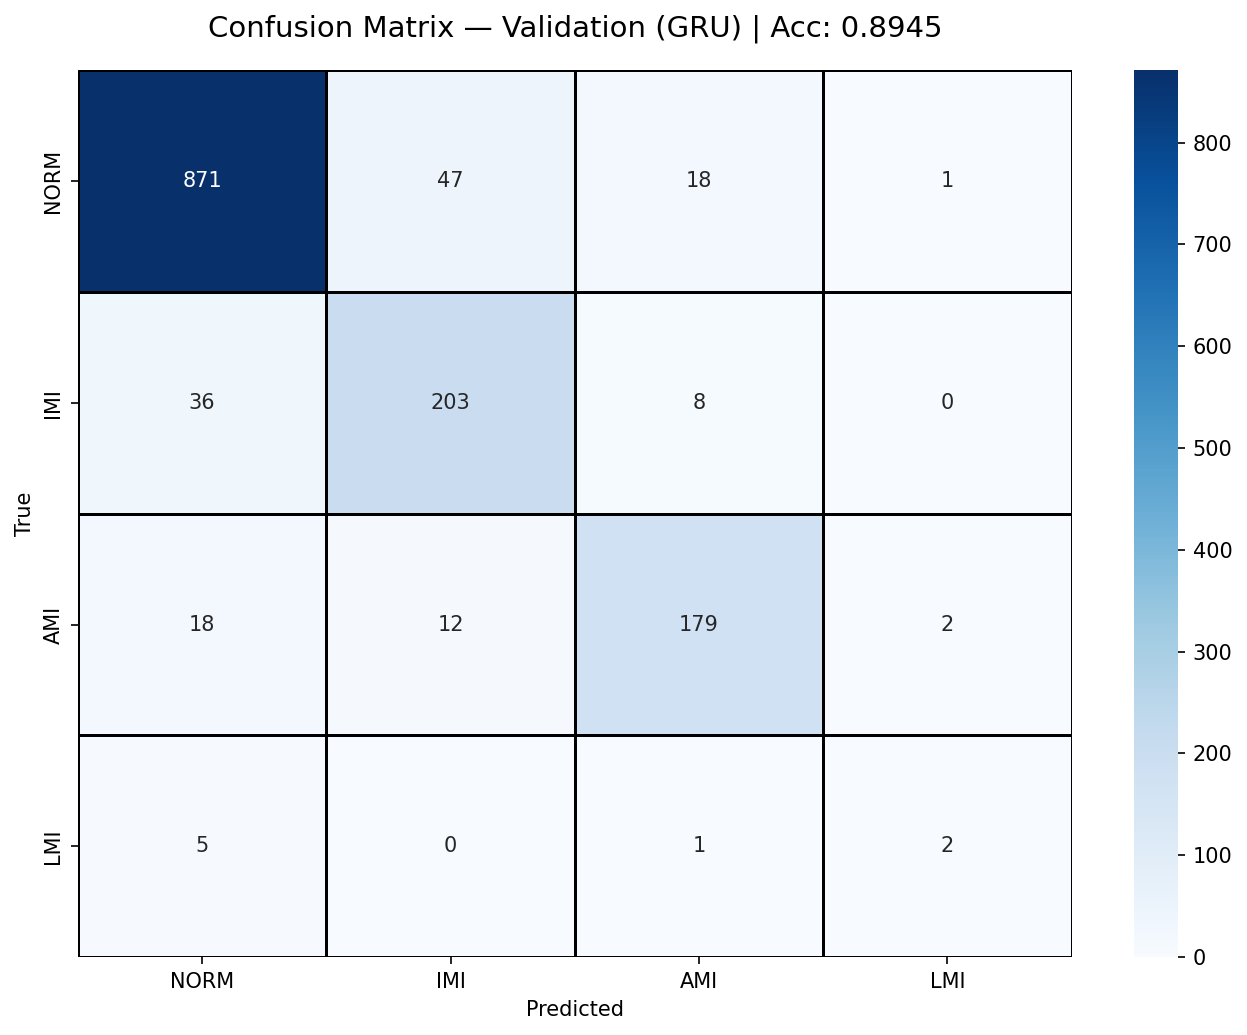


Test — Accuracy: 0.8958
              precision    recall  f1-score   support

        NORM       0.95      0.93      0.94      1915
         IMI       0.79      0.83      0.81       443
         AMI       0.81      0.84      0.82       389
         LMI       0.25      0.15      0.19        27

    accuracy                           0.90      2774
   macro avg       0.70      0.69      0.69      2774
weighted avg       0.89      0.90      0.90      2774



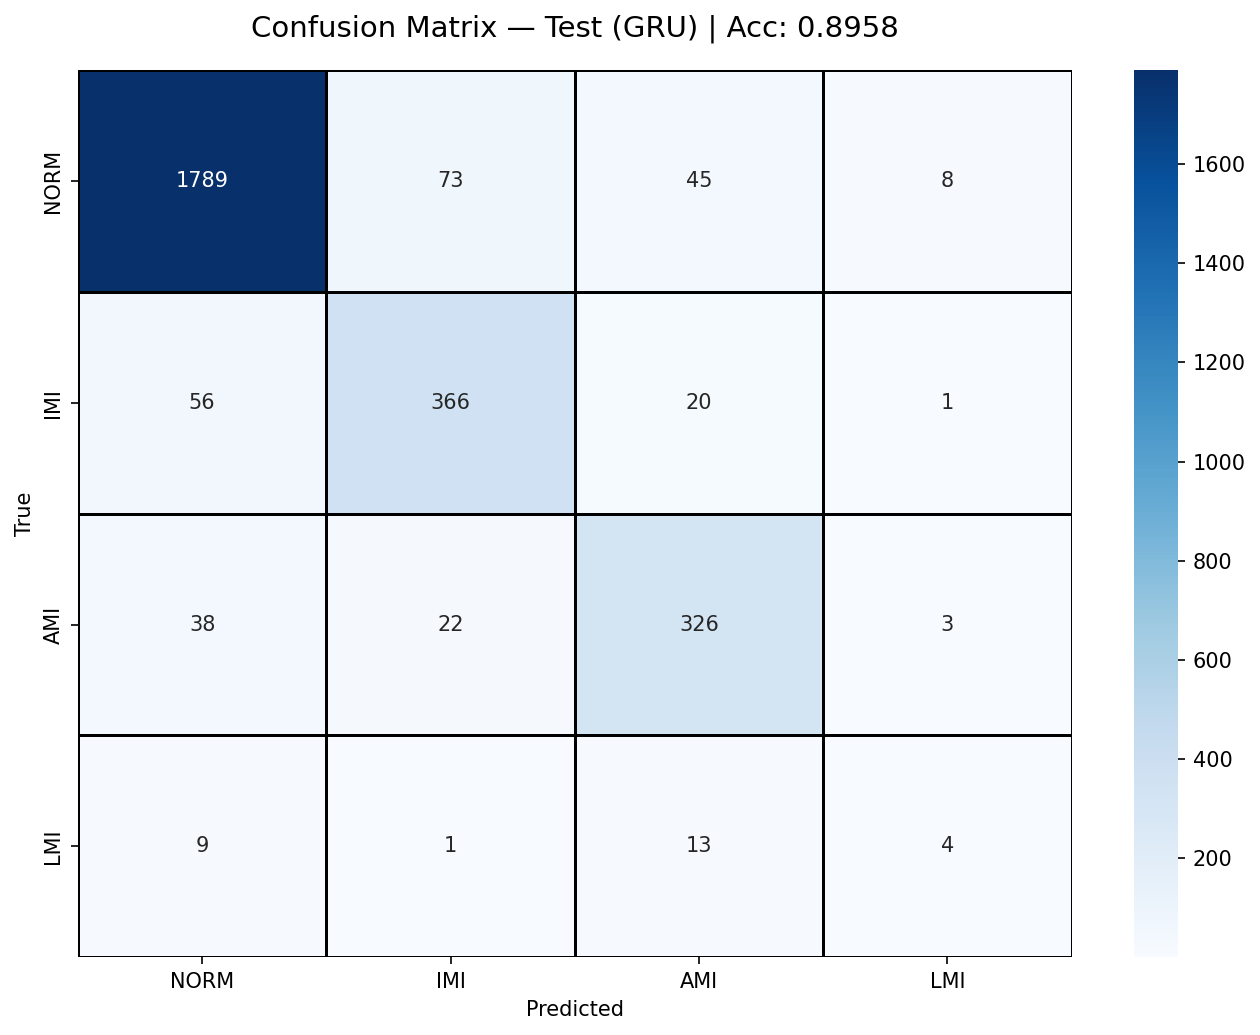

In [ ]:
# === GRU  (multi-layer) (Multiclass NORM–AMI–IMI–LMI) ===

# ---------------------------------------
# 1) Dataset Prep 
# ---------------------------------------
def to_numpy_array(a):
    if isinstance(a, torch.Tensor):
        return a.detach().cpu().numpy()
    return np.asarray(a)

def to_index(y):
    y_np = to_numpy_array(y)
    if y_np.ndim > 1 and y_np.shape[1] > 1:
        return np.argmax(y_np, axis=1).astype(np.int64)
    return y_np.reshape(-1).astype(np.int64)

y_train_idx = to_index(y_train)
y_val_idx   = to_index(y_val)
y_test_idx  = to_index(y_test)

num_classes = len(class_names)
in_channels = x_train.shape[2]
seq_len = x_train.shape[1]
print(f"Detected classes: {num_classes} | Channels: {in_channels} | Seq length: {seq_len}")

def make_loader(X, y, bs=128, shuffle=True):
    X = torch.tensor(X, dtype=torch.float32)  # [B,L,C] for GRU
    y = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X, y), batch_size=bs, shuffle=shuffle, num_workers=0)

train_loader = make_loader(x_train, y_train_idx)
val_loader   = make_loader(x_val, y_val_idx, shuffle=False)
test_loader  = make_loader(x_test, y_test_idx, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---------------------------------------
# 2) Model Definition — GRU 
# ---------------------------------------
class GRU_Only_Multi(nn.Module):
    def __init__(self, input_size, num_classes, hidden_size=128, num_layers=3, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):        # x: [B,L,C]
        out, _ = self.gru(x)     # [B,L,H]
        feat = out[:, -1, :]     # last timestep pooling
        return self.head(feat)

# ---------------------------------------
# 3) Training Setup
# ---------------------------------------
model = GRU_Only_Multi(input_size=in_channels, num_classes=num_classes, hidden_size=128, num_layers=3, dropout=0.2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-7)

def run_epoch(dl, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)  # xb: [B,L,C]
            out = model(xb)
            loss = criterion(out, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            pred = out.argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    return total_loss / total, correct / total

# ---------------------------------------
# 4) Training Loop
# ---------------------------------------
EPOCHS = 100
hist = {'tr_loss':[], 'va_loss':[], 'tr_acc':[], 'va_acc':[]}

for ep in range(1, EPOCHS+1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader, train=False)
    hist['tr_loss'].append(tr_loss); hist['va_loss'].append(va_loss)
    hist['tr_acc'].append(tr_acc);   hist['va_acc'].append(va_acc)
    print(f"Epoch {ep:02d}/{EPOCHS} | Loss {tr_loss:.4f}/{va_loss:.4f} | Acc {tr_acc:.4f}/{va_acc:.4f}")

# ---------------------------------------
# 5) Plot Curves 
# ---------------------------------------
ep = np.arange(1, len(hist['tr_loss'])+1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

ax1.plot(ep, hist['tr_loss'], label='Training Loss', linewidth=2.5)
ax1.plot(ep, hist['va_loss'], label='Validation Loss', linewidth=2.5, linestyle='--')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, hist['tr_acc'], label='Training Accuracy', linewidth=2.5)
ax2.plot(ep, hist['va_acc'], label='Validation Accuracy', linewidth=2.5, linestyle='--')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

fig.suptitle('Accuracy/Loss Curves — GRU', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ---------------------------------------
# 6) Evaluation + Confusion Matrix 
# ---------------------------------------
LABEL_ORDER = class_names
LABELS = list(range(len(class_names)))

def eval_model(dl, name):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(device)
            out = model(xb)
            preds = out.argmax(1).cpu().numpy()
            y_pred.append(preds)
            y_true.append(yb.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{name} — Accuracy: {acc:.4f}")
    print(classification_report(
        y_true, y_pred,
        target_names=LABEL_ORDER,
        labels=LABELS,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred, labels=LABELS)

    plt.figure(figsize=(9, 7), dpi=150)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=LABEL_ORDER,
        yticklabels=LABEL_ORDER,
        linewidths=0.7, linecolor='black'
    )
    plt.title(f'Confusion Matrix — {name} (GRU) | Acc: {acc:.4f}', fontsize=14, pad=16)
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    plt.show()

eval_model(val_loader,  "Validation")
eval_model(test_loader, "Test")


In [ ]:
# Save the trained model
model_name = 'GRU'
save_path = SAVE_DIR / f'{model_name}.pth'

# Ensure the directory exists
SAVE_DIR.mkdir(parents=True, exist_ok=True)
# Save the model state_dict
torch.save(model.state_dict(), save_path)
print(f"Model saved at {save_path}")


Model saved at /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-classification/model_pretrain_comparison/GRU.pth


### CNN + LSTM

Detected classes: 4 | Channels: 12 | Seq length: 1000
Epoch 01/100 | Loss 1.1947/0.8149 | Acc 0.4523/0.6785
Epoch 02/100 | Loss 0.7568/0.7049 | Acc 0.7330/0.7434
Epoch 03/100 | Loss 0.6765/0.6582 | Acc 0.7525/0.7619
Epoch 04/100 | Loss 0.6264/0.6367 | Acc 0.7691/0.7548
Epoch 05/100 | Loss 0.5803/0.6459 | Acc 0.7742/0.7705
Epoch 06/100 | Loss 0.5651/0.6082 | Acc 0.7786/0.7669
Epoch 07/100 | Loss 0.5383/0.5515 | Acc 0.7802/0.7712
Epoch 08/100 | Loss 0.5211/0.5369 | Acc 0.7895/0.7826
Epoch 09/100 | Loss 0.4984/0.5382 | Acc 0.7919/0.7840
Epoch 10/100 | Loss 0.4869/0.5295 | Acc 0.7982/0.7733
Epoch 11/100 | Loss 0.4800/0.5709 | Acc 0.8001/0.7840
Epoch 12/100 | Loss 0.4614/0.5509 | Acc 0.7991/0.7833
Epoch 13/100 | Loss 0.4494/0.5283 | Acc 0.8059/0.7783
Epoch 14/100 | Loss 0.4320/0.5527 | Acc 0.8043/0.7826
Epoch 15/100 | Loss 0.4243/0.4990 | Acc 0.8061/0.7826
Epoch 16/100 | Loss 0.4174/0.5730 | Acc 0.8139/0.7940
Epoch 17/100 | Loss 0.4113/0.5439 | Acc 0.8128/0.7940
Epoch 18/100 | Loss 0.3963/0

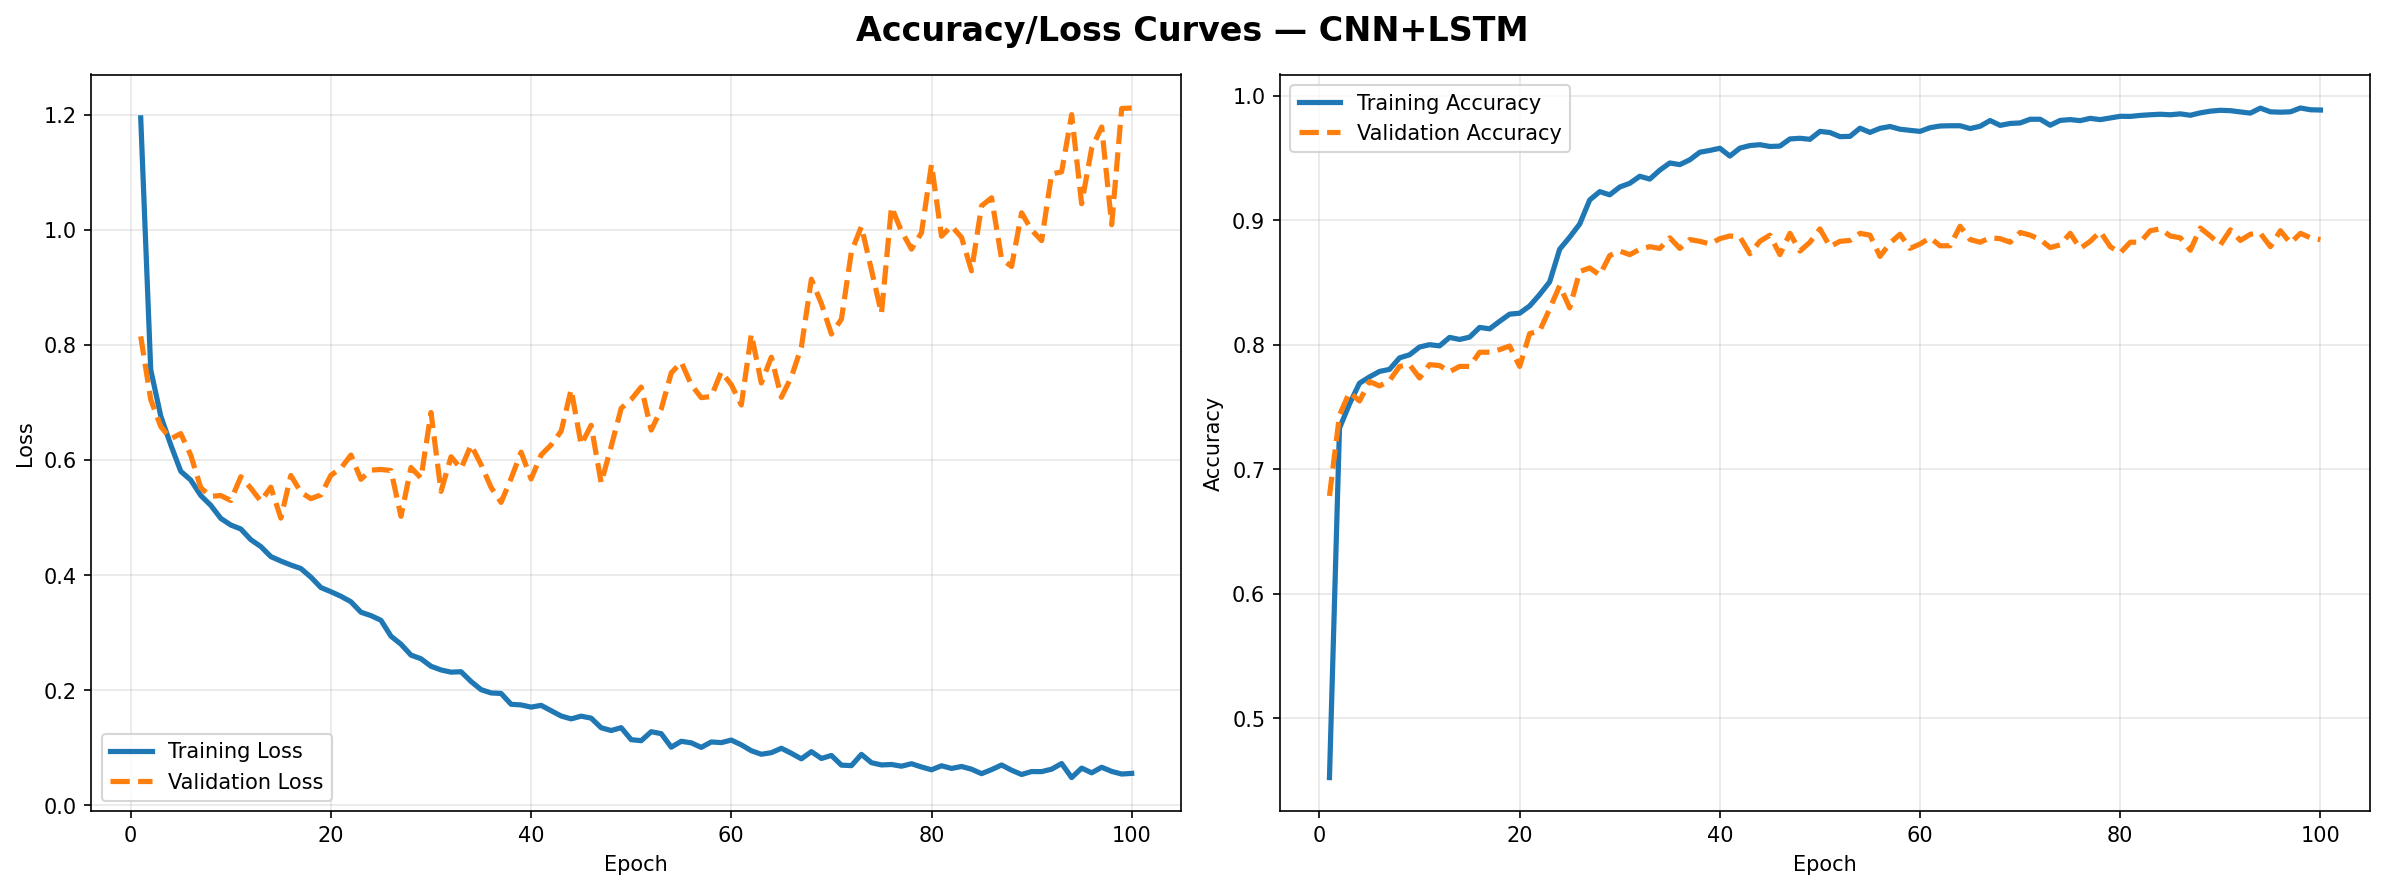


Validation — Accuracy: 0.8845
              precision    recall  f1-score   support

        NORM       0.90      0.96      0.93       937
         IMI       0.82      0.72      0.77       247
         AMI       0.89      0.77      0.83       211
         LMI       0.00      0.00      0.00         8

    accuracy                           0.88      1403
   macro avg       0.65      0.61      0.63      1403
weighted avg       0.88      0.88      0.88      1403



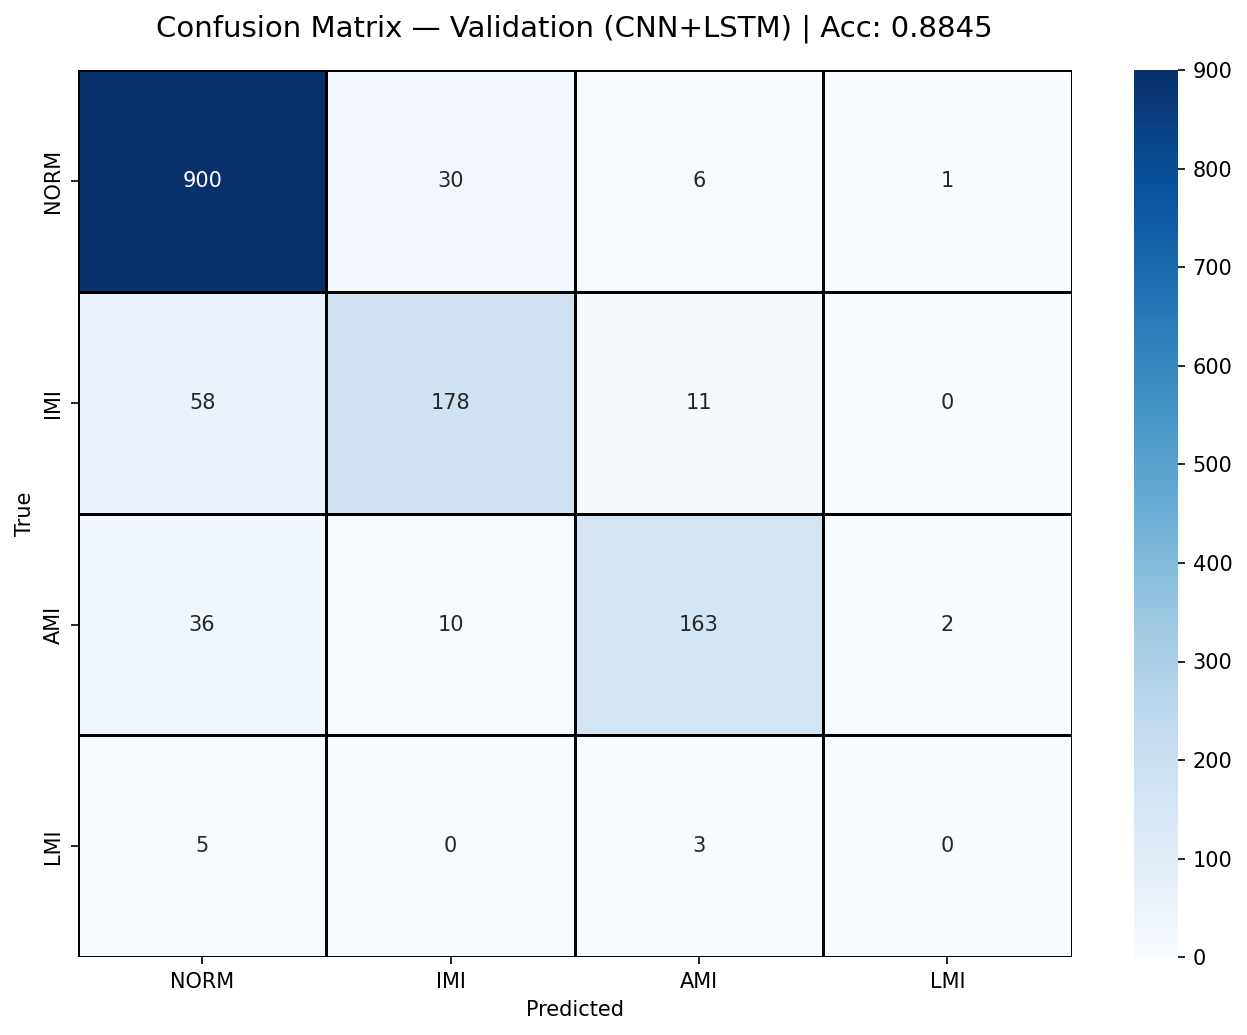


Test — Accuracy: 0.8810
              precision    recall  f1-score   support

        NORM       0.91      0.96      0.93      1915
         IMI       0.81      0.70      0.75       443
         AMI       0.82      0.78      0.80       389
         LMI       0.07      0.04      0.05        27

    accuracy                           0.88      2774
   macro avg       0.65      0.62      0.63      2774
weighted avg       0.87      0.88      0.88      2774



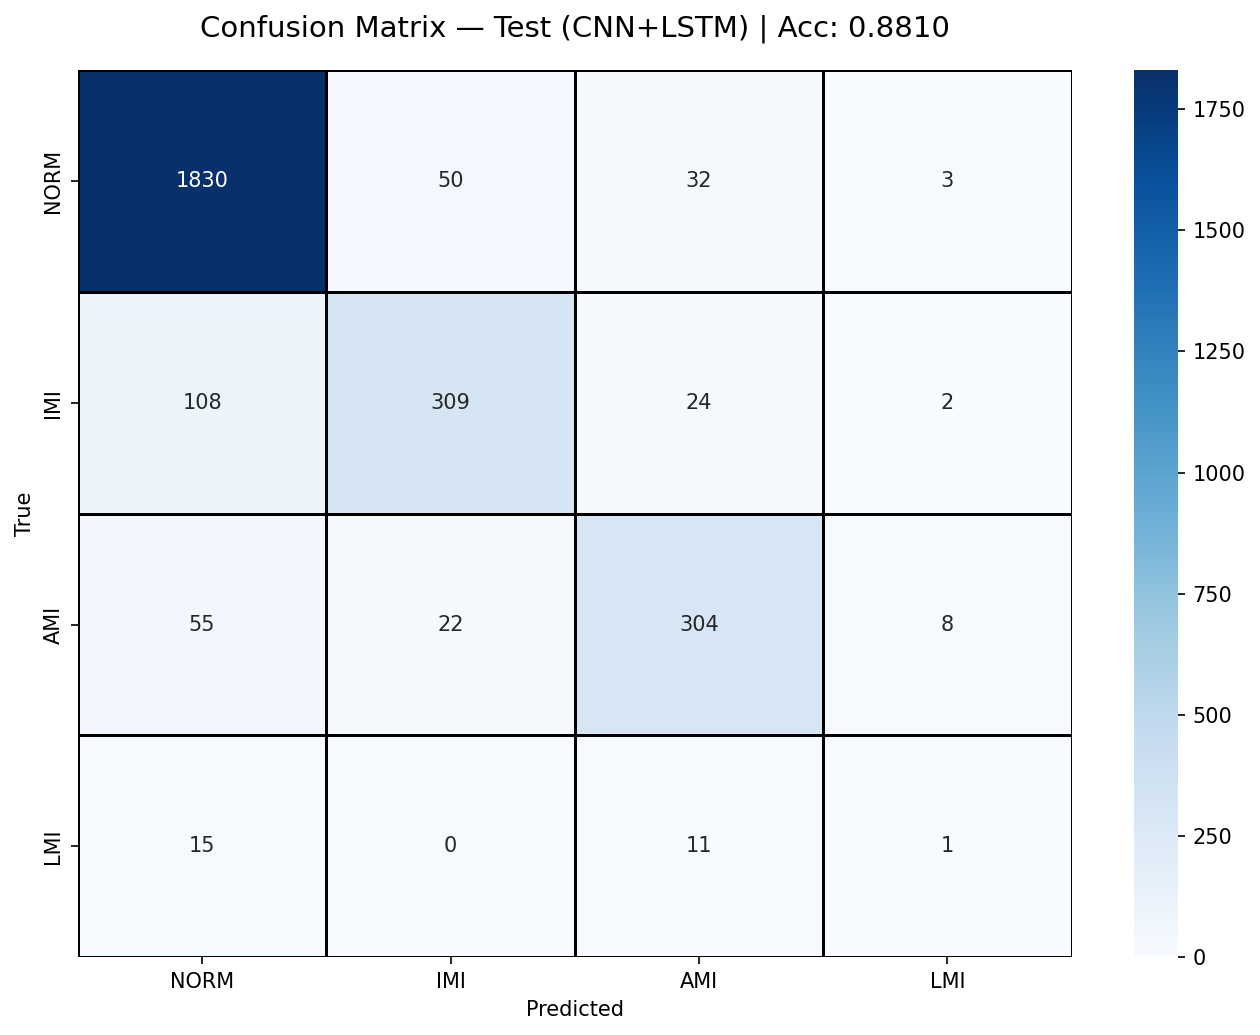

In [ ]:
# === CNN+LSTM no attention (Multiclass NORM–AMI–IMI–LMI) ===

# ---------------------------------------
# 1) Dataset Prep 
# ---------------------------------------
def to_numpy_array(a):
    if isinstance(a, torch.Tensor):
        return a.detach().cpu().numpy()
    return np.asarray(a)

def to_index(y):
    y_np = to_numpy_array(y)
    if y_np.ndim > 1 and y_np.shape[1] > 1:
        return np.argmax(y_np, axis=1).astype(np.int64)
    return y_np.reshape(-1).astype(np.int64)

y_train_idx = to_index(y_train)
y_val_idx   = to_index(y_val)
y_test_idx  = to_index(y_test)

num_classes = len(class_names)
in_channels = x_train.shape[2]
seq_len = x_train.shape[1]
print(f"Detected classes: {num_classes} | Channels: {in_channels} | Seq length: {seq_len}")

def make_loader(X, y, bs=128, shuffle=True):
    X = torch.as_tensor(to_numpy_array(X), dtype=torch.float32).permute(0, 2, 1)  # [B,C,L]
    y = torch.as_tensor(to_index(y), dtype=torch.long)
    return DataLoader(TensorDataset(X, y), batch_size=bs, shuffle=shuffle, num_workers=0)

train_loader = make_loader(x_train, y_train_idx)
val_loader   = make_loader(x_val, y_val_idx, shuffle=False)
test_loader  = make_loader(x_test, y_test_idx, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---------------------------------------
# 2) Baseline Model: CNN + LSTM 
# ---------------------------------------
class CNN_LSTM_Baseline(nn.Module):
    def __init__(self, in_channels=1, num_classes=4, lstm_hidden=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 32, 3, padding=1),
            nn.ReLU(), nn.BatchNorm1d(32),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, 3, padding=1),
            nn.ReLU(), nn.BatchNorm1d(64),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, 3, padding=1),
            nn.ReLU(), nn.BatchNorm1d(128),
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=lstm_hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=False,
            dropout=0.35  # stronger regularization
        )

        self.head = nn.Sequential(
            nn.Dropout(0.55),
            nn.Linear(lstm_hidden, 32),
            nn.ReLU(),
            nn.Dropout(0.55),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):          # x: [B,C,L]
        x = self.conv(x)           # [B,128,L']
        x = x.transpose(1,2)       # [B,T,128]
        out, _ = self.lstm(x)      # [B,T,H]
        feat = out[:, -1, :]       
        return self.head(feat)

# ---------------------------------------
# 3) Training Setup 
# ---------------------------------------
model = CNN_LSTM_Baseline(in_channels=in_channels, num_classes=num_classes, lstm_hidden=64).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-4) 

def run_epoch(dl, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device) 

            out = model(xb)
            loss = criterion(out, yb)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            pred = out.argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    return total_loss / total, correct / total

# ---------------------------------------
# 4) Training Loop
# ---------------------------------------
EPOCHS = 100  
hist = {'tr_loss':[], 'va_loss':[], 'tr_acc':[], 'va_acc':[]}

for ep in range(1, EPOCHS+1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader, train=False)
    hist['tr_loss'].append(tr_loss); hist['va_loss'].append(va_loss)
    hist['tr_acc'].append(tr_acc);   hist['va_acc'].append(va_acc)
    print(f"Epoch {ep:02d}/{EPOCHS} | Loss {tr_loss:.4f}/{va_loss:.4f} | Acc {tr_acc:.4f}/{va_acc:.4f}")

# ---------------------------------------
# 5) Plot Curves 
# ---------------------------------------
ep = np.arange(1, len(hist['tr_loss'])+1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

ax1.plot(ep, hist['tr_loss'], label='Training Loss', linewidth=2.5)
ax1.plot(ep, hist['va_loss'], label='Validation Loss', linewidth=2.5, linestyle='--')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, hist['tr_acc'], label='Training Accuracy', linewidth=2.5)
ax2.plot(ep, hist['va_acc'], label='Validation Accuracy', linewidth=2.5, linestyle='--')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

fig.suptitle('Accuracy/Loss Curves — CNN+LSTM', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ---------------------------------------
# 6) Evaluation + Confusion Matrix 
# ---------------------------------------
LABEL_ORDER = class_names
LABELS = list(range(len(class_names)))

def eval_model(dl, name):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(device)
            out = model(xb)
            preds = out.argmax(1).cpu().numpy()
            y_pred.append(preds)
            y_true.append(yb.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{name} — Accuracy: {acc:.4f}")
    print(classification_report(
        y_true, y_pred,
        target_names=LABEL_ORDER,
        labels=LABELS,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred, labels=LABELS)

    plt.figure(figsize=(9, 7), dpi=150)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=LABEL_ORDER,
        yticklabels=LABEL_ORDER,
        linewidths=0.7, linecolor='black'
    )
    plt.title(f'Confusion Matrix — {name} (CNN+LSTM) | Acc: {acc:.4f}', fontsize=14, pad=16)
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    plt.show()

eval_model(val_loader,  "Validation")
eval_model(test_loader, "Test")


In [ ]:
# Save the trained model
model_name = 'cnn_lstm'
save_path = SAVE_DIR / f'{model_name}.pth'

# Ensure the directory exists
SAVE_DIR.mkdir(parents=True, exist_ok=True)
# Save the model state_dict
torch.save(model.state_dict(), save_path)
print(f"Model saved at {save_path}")


Model saved at /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-classification/model_pretrain_comparison/cnn_lstm.pth
